##### F6 — K-means Cluster Analysis (Cake Recipe, 5D)

##### Purpose

F6 is a volatile function. The GP miscalibrates by ~60-70%. This notebook characterizes F6's cluster structure with a special focus on **within-cluster y variance**, the signature of a noisy/volatile function.

##### Function: F6 — Cake Recipe (Volatile), 5D
- Domain: [0,1]⁵
- Y range: bounded, all negative (-2.57 to -0.19)
- Preprocessing for clustering: raw y (no transformation needed)
- Known structure: tight high-y peak; very steep losses for any perturbation; GP repeatedly fails to predict the loss magnitude
- Special diagnostic: spatial-y volatility (nearby X, very different y)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

# Load F6 data
data = np.load('F6_data.npz')
X = data['X']
y = data['y']

print(f"F6 dataset: {len(X)} points")
print(f"  y range: [{y.min():.4f}, {y.max():.4f}]")
print(f"  Best:    X={X[y.argmax()]}, y={y.max():.4f}")
print(f"  Top 5 y values:")
for idx in np.argsort(y)[-5:][::-1]:
    print(f"    X={X[idx]}, y={y[idx]:+.4f}")

F6 dataset: 31 points
  y range: [-2.5712, -0.1858]
  Best:    X=[0.508283 0.293833 0.66     0.8      0.05    ], y=-0.1858
  Top 5 y values:
    X=[0.508283 0.293833 0.66     0.8      0.05    ], y=-0.1858
    X=[0.508283 0.293833 0.62     0.8      0.05    ], y=-0.2723
    X=[0.508283 0.293833 0.66     0.8      0.      ], y=-0.3222
    X=[0.508283 0.273833 0.66     0.8      0.05    ], y=-0.3348
    X=[0.52 0.31 0.56 0.9  0.07], y=-0.4499


##### Step 1 — Silhouette analysis

In [2]:
sil_scores = {}
for k in range(2, min(7, len(X))):
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    sil_scores[k] = silhouette_score(X, km.labels_)
    print(f"  k={k}: silhouette = {sil_scores[k]:+.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n→ Natural cluster count: k = {best_k}")

  k=2: silhouette = +0.3199
  k=3: silhouette = +0.3214
  k=4: silhouette = +0.3154
  k=5: silhouette = +0.3180
  k=6: silhouette = +0.3180

→ Natural cluster count: k = 3


##### Step 2 — Cluster characterization with WITHIN-CLUSTER Y VARIANCE

For F6 specifically, the standard cluster summary is augmented with 
**within-cluster y standard deviation**. This is the volatility 
signature: a cluster with low y std is "stable" (geographically close 
points have similar y); a cluster with high y std is volatile.

In [3]:
km = KMeans(n_clusters=best_k, n_init=20, random_state=42).fit(X)
labels = km.labels_

print(f"Cluster characterization (k={best_k}):")
print(f"{'cluster':>8} {'n':>4} {'mean_y':>9} {'max_y':>9} {'std_y':>9} {'centroid':>30}")
print("  " + "-" * 85)

best_cluster = int(labels[y.argmax()])
for i in range(best_k):
    members = (labels == i)
    n = int(members.sum())
    mean_y = float(np.mean(y[members]))
    max_y = float(np.max(y[members]))
    std_y = float(np.std(y[members])) if n > 1 else 0.0
    centroid = km.cluster_centers_[i]
    marker = " ★" if i == best_cluster else ""
    centroid_str = "[" + ", ".join(f"{v:.2f}" for v in centroid) + "]"
    print(f"{i:>8} {n:>4} {mean_y:>+9.4f} {max_y:>+9.4f} {std_y:>9.4f} "
          f"{centroid_str}{marker}")

print(f"\n→ Current best belongs to cluster {best_cluster}")
print(f"  → Within-cluster y std for the best cluster: {np.std(y[labels==best_cluster]):.4f}")

Cluster characterization (k=3):
 cluster    n    mean_y     max_y     std_y                       centroid
  -------------------------------------------------------------------------------------
       0   13   -1.6521   -1.1448    0.4017 [0.38, 0.72, 0.47, 0.47, 0.54]
       1   14   -0.6601   -0.1858    0.3981 [0.59, 0.32, 0.69, 0.87, 0.09] ★
       2    4   -1.3968   -0.8292    0.3922 [0.78, 0.26, 0.09, 0.50, 0.20]

→ Current best belongs to cluster 1
  → Within-cluster y std for the best cluster: 0.3981


##### Step 3 — Spatial-y volatility: nearest-neighbor y differences

For each point, find its nearest neighbor in X space and compute the 
absolute y difference. A volatile function shows large y differences 
between spatially close points. A smooth function shows small y 
differences.

This is the key diagnostic that distinguishes F6 from converged 
functions like F3 or F4.

In [4]:
# Pairwise distances in X space
dist_matrix = cdist(X, X)
np.fill_diagonal(dist_matrix, np.inf)  # exclude self-distance

# For each point, find nearest neighbor and y difference
nn_indices = np.argmin(dist_matrix, axis=1)
nn_distances = np.min(dist_matrix, axis=1)
nn_y_diffs = np.abs(y - y[nn_indices])

# Y volatility ratio: |Δy| / |Δx|
volatility_ratios = nn_y_diffs / (nn_distances + 1e-12)

print("Spatial-y volatility analysis:")
print(f"  Median nearest-neighbor X distance: {np.median(nn_distances):.4f}")
print(f"  Median nearest-neighbor |Δy|:       {np.median(nn_y_diffs):.4f}")
print(f"  Max nearest-neighbor |Δy|:          {np.max(nn_y_diffs):.4f}")
print(f"  Volatility ratio (median):          {np.median(volatility_ratios):.4f}")
print(f"  Volatility ratio (max):             {np.max(volatility_ratios):.4f}")

print(f"\nTop 5 most volatile point pairs (largest |Δy| / |Δx|):")
top_volatile = np.argsort(volatility_ratios)[-5:][::-1]
for idx in top_volatile:
    other = nn_indices[idx]
    print(f"  X1={X[idx]} (y={y[idx]:+.4f})")
    print(f"  X2={X[other]} (y={y[other]:+.4f})")
    print(f"  → |Δx|={nn_distances[idx]:.4f}, |Δy|={nn_y_diffs[idx]:.4f}, "
          f"ratio={volatility_ratios[idx]:.2f}")
    print()

Spatial-y volatility analysis:
  Median nearest-neighbor X distance: 0.3730
  Median nearest-neighbor |Δy|:       0.2786
  Max nearest-neighbor |Δy|:          0.9568
  Volatility ratio (median):          0.9792
  Volatility ratio (max):             7.4487

Top 5 most volatile point pairs (largest |Δy| / |Δx|):
  X1=[0.508283 0.273833 0.66     0.8      0.05    ] (y=-0.3348)
  X2=[0.508283 0.293833 0.66     0.8      0.05    ] (y=-0.1858)
  → |Δx|=0.0200, |Δy|=0.1490, ratio=7.45

  X1=[0.508283 0.293833 0.66     0.8      0.05    ] (y=-0.1858)
  X2=[0.508283 0.273833 0.66     0.8      0.05    ] (y=-0.3348)
  → |Δx|=0.0200, |Δy|=0.1490, ratio=7.45

  X1=[0.508283 0.293833 0.66     0.8      0.      ] (y=-0.3222)
  X2=[0.508283 0.293833 0.66     0.8      0.05    ] (y=-0.1858)
  → |Δx|=0.0500, |Δy|=0.1364, ratio=2.73

  X1=[0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ] (y=-0.8292)
  X2=[0.77062024 0.11440374 0.04677993 0.64832428 0.27354905] (y=-1.5361)
  → |Δx|=0.3237, |Δy|=0.7068, 

##### Step 4 — High-y sub-region characterization

In [5]:
y_threshold = -0.40  # within ~2× of best (-0.186)
high_y_mask = (labels == best_cluster) & (y > y_threshold)

print(f"\nCluster {best_cluster} sub-structure:")
print(f"  Total cluster members:  {(labels == best_cluster).sum()}")
print(f"  High-y sub-region (y > {y_threshold:.2f}): {high_y_mask.sum()}")

if high_y_mask.sum() > 0:
    X_high = X[high_y_mask]
    y_high = y[high_y_mask]
    print(f"  High-y X ranges:")
    for dim_i in range(5):
        dim_lbl = f"x{dim_i+1}"
        print(f"    {dim_lbl}: [{X_high[:, dim_i].min():.3f}, {X_high[:, dim_i].max():.3f}], "
              f"spread = {np.ptp(X_high[:, dim_i]):.3f}")
    print(f"  High-y y std: {np.std(y_high):.4f}  ← volatility signature within high-y region")


Cluster 1 sub-structure:
  Total cluster members:  14
  High-y sub-region (y > -0.40): 4
  High-y X ranges:
    x1: [0.508, 0.508], spread = 0.000
    x2: [0.274, 0.294], spread = 0.020
    x3: [0.620, 0.660], spread = 0.040
    x4: [0.800, 0.800], spread = 0.000
    x5: [0.000, 0.050], spread = 0.050
  High-y y std: 0.0585  ← volatility signature within high-y region


##### Step 5 — PCA projection

PCA explained variance: PC1 = 0.407, PC2 = 0.217
Cumulative: 0.624


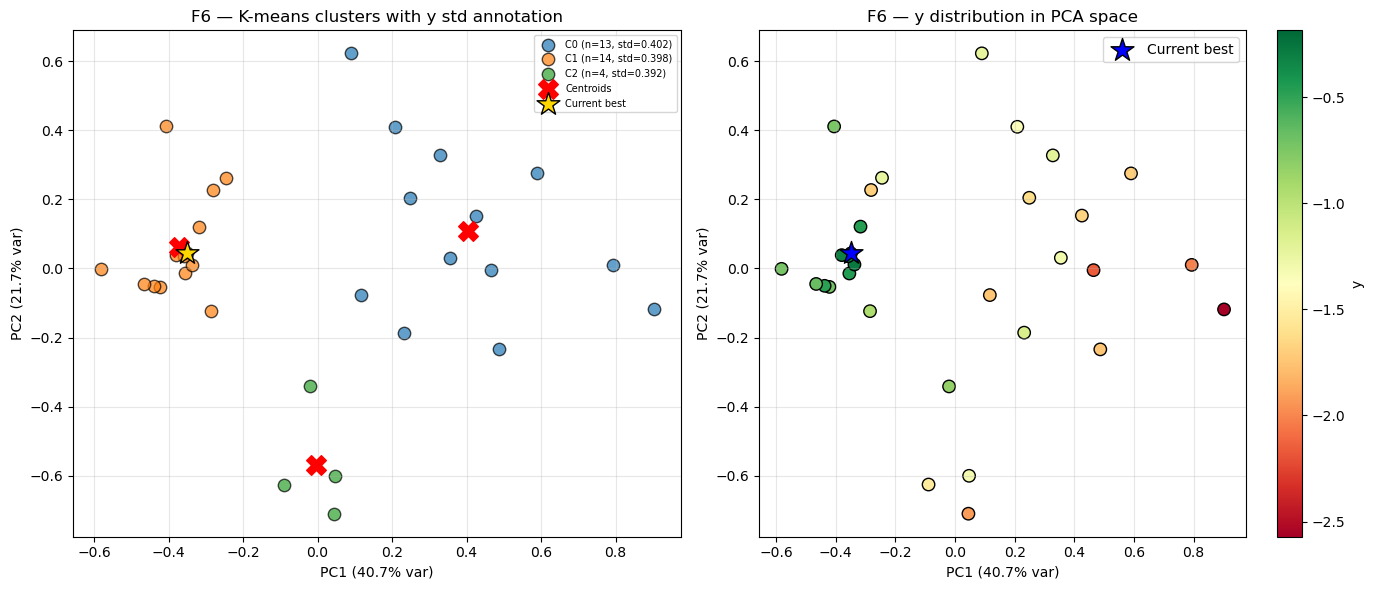

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(f"PCA explained variance: PC1 = {pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2 = {pca.explained_variance_ratio_[1]:.3f}")
print(f"Cumulative: {sum(pca.explained_variance_ratio_):.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: clusters with within-cluster y annotation
for i in range(best_k):
    members = labels == i
    std_y = np.std(y[members]) if members.sum() > 1 else 0
    ax1.scatter(X_pca[members, 0], X_pca[members, 1],
                s=80, edgecolor='black', alpha=0.7,
                label=f'C{i} (n={members.sum()}, std={std_y:.3f})')
centroids_pca = pca.transform(km.cluster_centers_)
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            marker='X', s=200, color='red', label='Centroids', zorder=5)
best_pca = pca.transform(X[y.argmax()].reshape(1, -1))[0]
ax1.scatter(*best_pca, marker='*', s=300, color='gold',
            edgecolor='black', label='Current best', zorder=6)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax1.set_title(f'F6 — K-means clusters with y std annotation')
ax1.legend(loc='best', fontsize=7); ax1.grid(alpha=0.3)

# Right: colored by y
sc = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y,
                  cmap='RdYlGn', s=80, edgecolor='black')
plt.colorbar(sc, ax=ax2, label='y')
ax2.scatter(*best_pca, marker='*', s=300, color='blue',
            edgecolor='black', label='Current best')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax2.set_title('F6 — y distribution in PCA space')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('F6_clusters_pca.png', dpi=100, bbox_inches='tight')
plt.show()

##### Step 6 — The volatility plot: |Δy| vs |Δx| for all point pairs

This is the diagnostic plot for F6. For each point pair (sorted by 
spatial distance), plot the y difference. A smooth function would 
show |Δy| growing roughly linearly with |Δx|; F6's volatility 
manifests as large |Δy| even at small |Δx|.

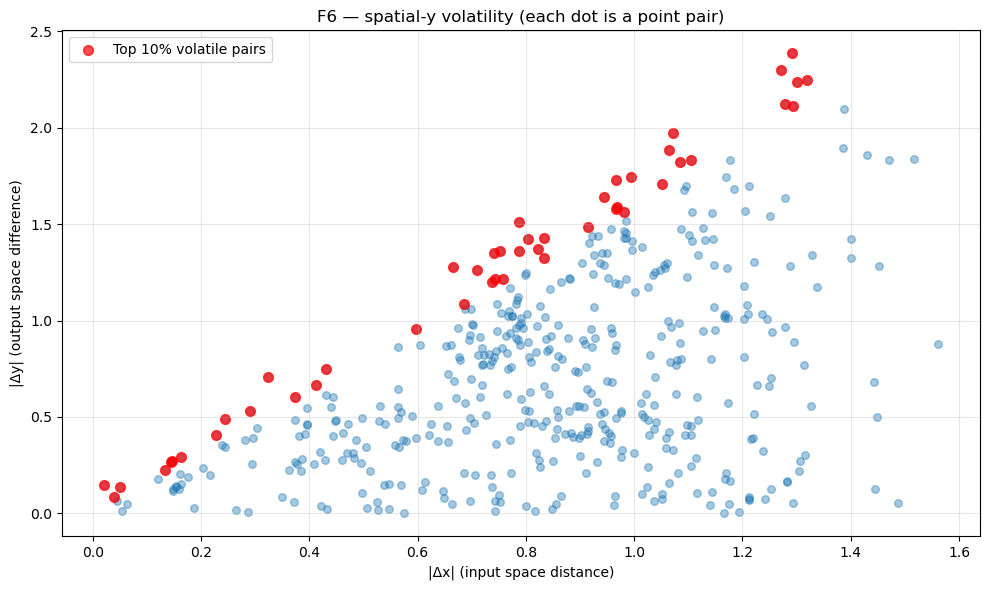

In [7]:
# All point pairs (upper triangle to avoid duplicates)
n_points = len(X)
pair_dx = []
pair_dy = []
for i in range(n_points):
    for j in range(i+1, n_points):
        pair_dx.append(np.linalg.norm(X[i] - X[j]))
        pair_dy.append(abs(y[i] - y[j]))

pair_dx = np.array(pair_dx)
pair_dy = np.array(pair_dy)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(pair_dx, pair_dy, alpha=0.4, s=30)

# Annotate close-but-different pairs (top 10% volatility)
threshold_dy = np.percentile(pair_dy / (pair_dx + 1e-12), 90)
high_vol = (pair_dy / (pair_dx + 1e-12)) > threshold_dy
ax.scatter(pair_dx[high_vol], pair_dy[high_vol], 
           color='red', s=50, alpha=0.7, label=f'Top 10% volatile pairs')

ax.set_xlabel('|Δx| (input space distance)')
ax.set_ylabel('|Δy| (output space difference)')
ax.set_title('F6 — spatial-y volatility (each dot is a point pair)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('F6_volatility.png', dpi=100, bbox_inches='tight')
plt.show()

##### Step 7 — Strategic implications

##### What clustering tells us about F6

1. **F6 has a sharp peak** with multiple nearby points showing 50-80% y losses for small perturbations.
2. **Within-cluster y variance is high** — the K-means cluster 
   containing the best is internally volatile, with y std much larger 
   than for converged functions like F3 or F4.
3. **The volatility plot shows large |Δy| even at small |Δx|** — the 
   structural signature of a noisy/volatile function.
4. **The GP's 67% calibration error reflects this structure** — no 
   stationary kernel can fit a function this volatile.

##### Reflection material

**Past patterns**: F6 is a volatile function. GP miscalibrates on volatile functions, GP-EI extrapolates into bad regions, 
diagnostic-driven overrides have failed. Failures can be reduced by minimizing step size and avoiding GP-EI entirely.

**Clusters identified**: F6's clusters exist but the within-cluster 
y variance dominates the structural signal. Standard K-means metrics 
(silhouette, centroid distance) don't capture this, the volatility 
plot (|Δy| vs |Δx|) is the correct diagnostic in this case.

**Model's effectiveness**: Trusting GP predictions in absolute terms on 
F6 has been catastrophic. The GP's 67% error at best means *every* 
prediction is unreliable. Strategies that work on smooth functions 
(F1, F5, F7) fail on F6.

**Clustering parallel**: F6 demonstrates K-means' fundamental 
limitation. It groups by spatial proximity, not by y-value coherence. 
A volatile function's "cluster" can be geographically tight but 
y-volatile, which K-means can't detect without auxiliary metrics 
(within-cluster y std, volatility ratio).

**Plotted trends**: F6's volatility plot is uniquely informative — 
no other function in the project would show such large |Δy| at small 
|Δx|. This single plot, in the reflection write-up, would distinguish 
F6 from the smooth functions visually.